In [1]:
from bauer.models import FlexibleNoiseComparisonModel
from bauer.utils.data import load_garcia2022

In [2]:
df = load_garcia2022()

In [4]:
model = FlexibleNoiseComparisonModel(df)

model.build_estimation_model(df)

In [6]:
idata = model.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_spline1_mu, n1_evidence_sd_spline1_sd, n1_evidence_sd_spline1_offset, n1_evidence_sd_spline2_mu, n1_evidence_sd_spline2_sd, n1_evidence_sd_spline2_offset, n1_evidence_sd_spline3_mu, n1_evidence_sd_spline3_sd, n1_evidence_sd_spline3_offset, n1_evidence_sd_spline4_mu, n1_evidence_sd_spline4_sd, n1_evidence_sd_spline4_offset, n1_evidence_sd_spline5_mu, n1_evidence_sd_spline5_sd, n1_evidence_sd_spline5_offset, n2_evidence_sd_spline1_mu, n2_evidence_sd_spline1_sd, n2_evidence_sd_spline1_offset, n2_evidence_sd_spline2_mu, n2_evidence_sd_spline2_sd, n2_evidence_sd_spline2_offset, n2_evidence_sd_spline3_mu, n2_evidence_sd_spline3_sd, n2_evidence_sd_spline3_offset, n2_evidence_sd_spline4_mu, n2_evidence_sd_spline4_sd, n2_evidence_sd_spline4_offset, n2_evidence_sd_spline5_mu, n2_evidence_sd_spline5_sd, n2_evidence_sd_spline5_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 603 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 18 divergences after tuning. Increase `target_accept` or reparameterize.


In [8]:
n1_evidence_sd = model.get_sd_curve(idata, variable='n1_evidence_sd', group=True)
n2_evidence_sd = model.get_sd_curve(idata, variable='n2_evidence_sd', group=True)

In [45]:
import pandas as pd
evidence_sd = pd.concat((n1_evidence_sd, n2_evidence_sd), axis=1).stack().to_frame('sd')

In [47]:
import arviz as az
def get_hdi(d):
    return pd.Series(az.hdi(d.values, hdi_prob=0.95), index=['hdi025', 'hdi975'])

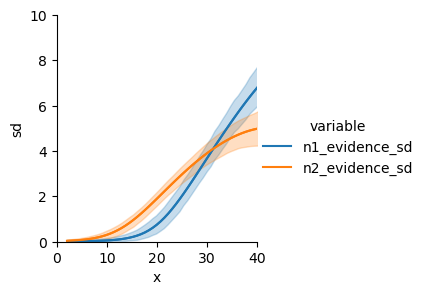

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
from bauer.utils.plotting import plot_prediction

evidence_sd_mean = evidence_sd.groupby(['x', 'variable'])['sd'].mean().to_frame('sd')
evidence_sd_hdi = evidence_sd.groupby(['x', 'variable'])['sd'].apply(get_hdi).unstack()

stats = evidence_sd_mean.join(evidence_sd_hdi)

g = sns.FacetGrid(stats.reset_index(), hue='variable')
g.map(plt.plot, 'x', 'sd')
g.map_dataframe(plot_prediction, x='x', y='sd')
g.add_legend()
g.set(xlim=(0, 40), ylim=(0, 10))

In [93]:
import numpy as np
df['log(n2/n1)'] = np.log(df['n2'] / df['n1'])

df['n2 - n1'] = df['n2'] - df['n1']

In [94]:
ppc = model.ppc(df, idata)

Sampling: [ll_bernoulli]


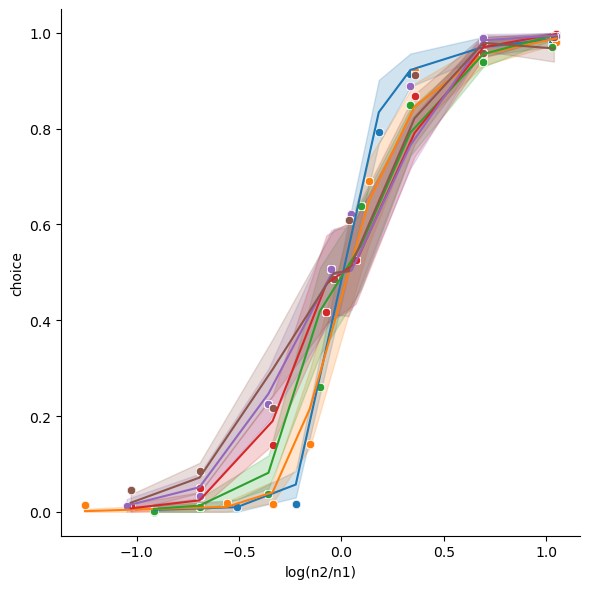

In [97]:
tmp = ppc.groupby(['subject', 'n1', 'log(n2/n1)']).mean().groupby(['n1', 'log(n2/n1)']).mean().stack([0, 1]).to_frame('predicted_choice')

d = df.groupby(['subject', 'n1', 'log(n2/n1)'])[['choice']].mean().groupby(['n1', 'log(n2/n1)']).mean()

tmp = tmp.join(d)



def get_hdi(d):
    hdi = az.hdi(d.values, hdi_prob=0.95)
    return hdi[0], hdi[1]

g = sns.FacetGrid(tmp.reset_index(), hue='n1', height=6.)

g.map_dataframe(sns.lineplot, x='log(n2/n1)', y='predicted_choice', errorbar=get_hdi)
g.map_dataframe(sns.scatterplot, x='log(n2/n1)', y='choice')